# Exploratory Data Analysis (EDA) - NHANES Demographics (`DEMO_L.xpt`)

This notebook performs a comprehensive exploratory and descriptive analysis of the **NHANES August 2021 - August 2023** Demographics dataset (`DEMO_L.xpt`).

### Objectives:
1. **Load Data**: Read `DEMO_L.xpt` from the Demographics data directory.
2. **Structure & Dimensions**: Inspect total rows, columns, memory usage, and data types.
3. **Feature Inventory**: Display all dataset features with data types and sample values.
4. **Missingness Analysis**: Calculate missing value counts, percentages, and identify incomplete features.
5. **Descriptive Statistics**: Summarize distributions (mean, std, median, IQR, min/max, skewness).
6. **Key Demographic Analysis**: Frequency distributions for age, gender, race/ethnicity, household size, and income ratio.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.style.use('ggplot')

# Locate DEMO_L.xpt file dynamically
current_dir = Path.cwd()
xpt_matches = list(current_dir.rglob('DEMO_L.xpt'))

if xpt_matches:
    file_path = xpt_matches[0]
else:
    # Fallback to known relative path from mir-medical-intelligence root
    file_path = Path('DATASETS/data/raw/NHANES/NHANES August 2021 - Auguest 2023/Data, Documentation, Codebooks/Demographics Data - Continuous NHANES/DEMO_L.xpt')

print(f"[INFO] Loading dataset from: {file_path.resolve()}")
df = pd.read_sas(file_path)
print(f"[SUCCESS] Dataset successfully loaded into pandas DataFrame!")

[INFO] Loading dataset from: F:\Google Drive (Mir Consulting)\mir-medical-intelligence\mir-medical-intelligence\DATASETS\data\raw\NHANES\NHANES August 2021 - Auguest 2023\Data, Documentation, Codebooks\Demographics Data - Continuous NHANES\DEMO_L.xpt
[SUCCESS] Dataset successfully loaded into pandas DataFrame!


## 1. High-Level Dataset Overview & Structure

In [5]:
num_rows, num_cols = df.shape
memory_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)

print("="*60)
print(f"DATASET SUMMARY OVERVIEW")
print("="*60)
print(f"Total Number of Rows (Participants) : {num_rows:,}")
print(f"Total Number of Features (Columns)  : {num_cols}")
print(f"Total Memory Usage                 : {memory_mb:.2f} MB")
print("="*60)

# Preview first 5 rows
display(df.head())

DATASET SUMMARY OVERVIEW
Total Number of Rows (Participants) : 11,933
Total Number of Features (Columns)  : 27
Total Memory Usage                 : 2.46 MB


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,DMQMILIZ,DMDBORN4,DMDYRUSR,DMDEDUC2,DMDMARTZ,RIDEXPRG,DMDHHSIZ,DMDHRGND,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVSTRA,SDMVPSU,INDFMPIR
0,130378.000,12.000,2.000,1.000,43.000,NaN,5.000,6.000,2.000,NaN,2.000,2.000,6.000,5.000,1.000,NaN,4.000,NaN,NaN,NaN,NaN,NaN,50055.451,54374.464,173.000,2.000,5.000
1,130379.000,12.000,2.000,1.000,66.000,NaN,3.000,3.000,2.000,NaN,2.000,1.000,NaN,5.000,1.000,NaN,2.000,NaN,NaN,NaN,NaN,NaN,29087.451,34084.722,173.000,2.000,5.000
2,130380.000,12.000,2.000,2.000,44.000,NaN,2.000,2.000,1.000,NaN,2.000,2.000,6.000,3.000,1.000,2.000,7.000,NaN,NaN,NaN,NaN,NaN,80062.674,81196.278,174.000,1.000,1.410
3,130381.000,12.000,2.000,2.000,5.000,NaN,5.000,7.000,1.000,71.000,NaN,1.000,NaN,NaN,NaN,NaN,2.000,2.000,2.000,2.000,3.000,NaN,38807.269,55698.607,182.000,2.000,1.530
4,130382.000,12.000,2.000,1.000,2.000,NaN,3.000,3.000,2.000,34.000,NaN,1.000,NaN,NaN,NaN,NaN,4.000,2.000,2.000,3.000,1.000,2.000,30607.520,36434.146,182.000,2.000,3.600


## 2. Complete Feature List & Data Types

Below is the complete inventory of features in `DEMO_L.xpt`, including their indices, data types, non-null counts, and sample values.

In [6]:
feature_info = pd.DataFrame({
    'Feature_Index': range(1, num_cols + 1),
    'Feature_Name': df.columns,
    'Data_Type': df.dtypes.values,
    'Non_Null_Count': df.notnull().sum().values,
    'Null_Count': df.isnull().sum().values,
    'Null_Percentage (%)': (df.isnull().sum().values / num_rows * 100).round(2),
    'Unique_Values': [df[col].nunique() for col in df.columns],
    'Sample_Value': [df[col].dropna().iloc[0] if not df[col].dropna().empty else np.nan for col in df.columns]
})

display(feature_info)

,Feature_Index,Feature_Name,Data_Type,Non_Null_Count,Null_Count,Null_Percentage (%),Unique_Values,Sample_Value
0,1,SEQN,float64,11933,0,0.000,11933,130378.000
1,2,SDDSRVYR,float64,11933,0,0.000,1,12.000
2,3,RIDSTATR,float64,11933,0,0.000,2,2.000
3,4,RIAGENDR,float64,11933,0,0.000,2,1.000
4,5,RIDAGEYR,float64,11933,0,0.000,81,43.000
5,6,RIDAGEMN,float64,377,11556,96.840,25,24.000
6,7,RIDRETH1,float64,11933,0,0.000,5,5.000
7,8,RIDRETH3,float64,11933,0,0.000,6,6.000
8,9,RIDEXMON,float64,8860,3073,25.750,2,2.000
9,10,RIDEXAGM,float64,2787,9146,76.640,240,71.000


## 3. Missing Data Analysis

Understanding missingness patterns is essential for health survey data like NHANES, where certain questions are age-restricted or conditionally asked (skip patterns).

Features with 100% complete data : 12 / 27
Features with missing values    : 15 / 27
Features with >50% missing data  : 9 / 27


,Feature,Missing_Count,Missing_Percentage (%)
0,RIDAGEMN,11556,96.840
1,RIDEXPRG,10430,87.400
2,DMDYRUSR,10058,84.290
3,DMDHSEDZ,9806,82.180
4,RIDEXAGM,9146,76.640
5,DMDHREDZ,8187,68.610
6,DMDHRMAZ,7913,66.310
7,DMDHRGND,7818,65.520
8,DMDHRAGZ,7809,65.440
9,DMDMARTZ,4141,34.700


C:\Users\mirab\AppData\Local\Temp\ipykernel_20448\2946547888.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=missing_df, x='Missing_Percentage (%)', y='Feature', palette='viridis')


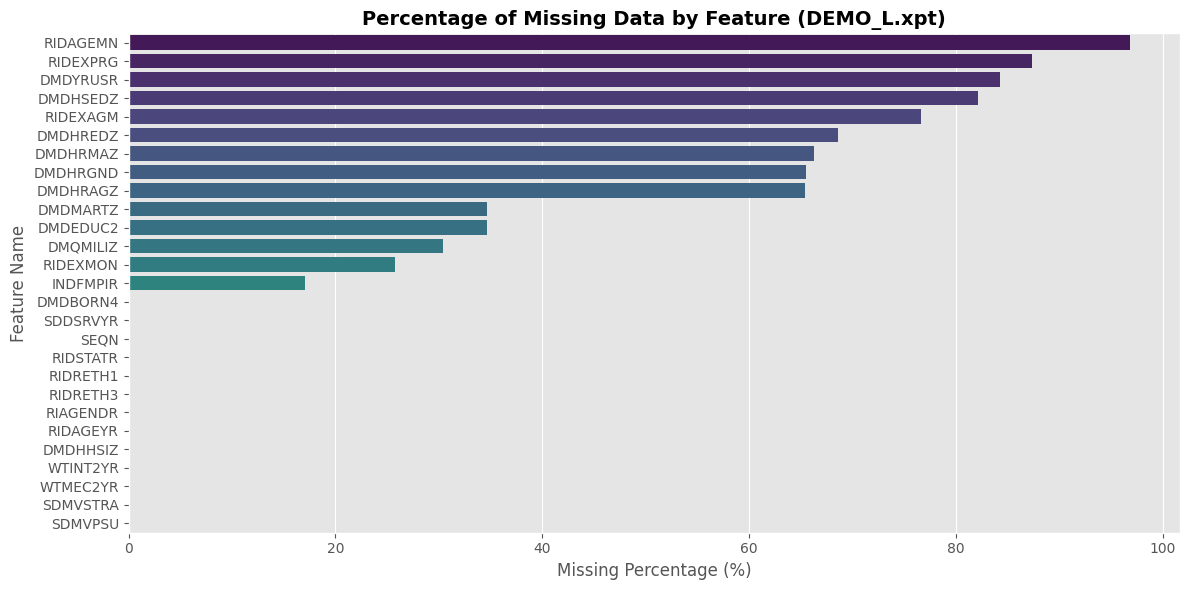

In [7]:
missing_df = pd.DataFrame({
    'Feature': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values(by='Missing_Percentage (%)', ascending=False).reset_index(drop=True)

print(f"Features with 100% complete data : {(missing_df['Missing_Count'] == 0).sum()} / {num_cols}")
print(f"Features with missing values    : {(missing_df['Missing_Count'] > 0).sum()} / {num_cols}")
print(f"Features with >50% missing data  : {(missing_df['Missing_Percentage (%)'] > 50).sum()} / {num_cols}")

display(missing_df)

# Visualization of Missing Data Percentage
plt.figure(figsize=(12, 6))
sns.barplot(data=missing_df, x='Missing_Percentage (%)', y='Feature', palette='viridis')
plt.title('Percentage of Missing Data by Feature (DEMO_L.xpt)', fontsize=14, fontweight='bold')
plt.xlabel('Missing Percentage (%)')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

## 4. Descriptive Statistics & Summary Metrics

In [8]:
desc_stats = df.describe().T
desc_stats['median'] = df.median()
desc_stats['IQR'] = desc_stats['75%'] - desc_stats['25%']
desc_stats['skewness'] = df.skew()
desc_stats['kurtosis'] = df.kurtosis()

# Reorder columns for clarity
desc_stats = desc_stats[['count', 'mean', 'std', 'min', '25%', 'median', '75%', 'max', 'IQR', 'skewness', 'kurtosis']]

print("DESCRIPTIVE STATISTICS SUMMARY:")
display(desc_stats)

DESCRIPTIVE STATISTICS SUMMARY:


,count,mean,std,min,25%,median,75%,max,IQR,skewness,kurtosis
SEQN,11933.000,136344.000,3444.905,130378.000,133361.000,136344.000,139327.000,142310.000,5966.000,0.000,-1.200
SDDSRVYR,11933.000,12.000,0.000,12.000,12.000,12.000,12.000,12.000,0.000,0.000,0.000
RIDSTATR,11933.000,1.742,0.437,1.000,1.000,2.000,2.000,2.000,1.000,-1.109,-0.770
RIAGENDR,11933.000,1.533,0.499,1.000,1.000,2.000,2.000,2.000,1.000,-0.132,-1.983
RIDAGEYR,11933.000,38.318,25.602,0.000,13.000,37.000,62.000,80.000,49.000,0.086,-1.414
RIDAGEMN,377.000,11.629,6.805,0.000,6.000,11.000,17.000,24.000,11.000,0.066,-1.063
RIDRETH1,11933.000,3.105,1.076,1.000,3.000,3.000,4.000,5.000,1.000,-0.002,-0.126
RIDRETH3,11933.000,3.321,1.518,1.000,3.000,3.000,4.000,7.000,1.000,1.042,0.877
RIDEXMON,8860.000,1.520,0.500,1.000,1.000,2.000,2.000,2.000,1.000,-0.081,-1.994
RIDEXAGM,2787.000,121.909,67.159,0.000,66.000,122.000,179.500,239.000,113.500,-0.036,-1.132


## 5. Key Demographic Distribution Breakdown

Exploring foundational NHANES variables:
- `SEQN`: Respondent Sequence Number
- `RIAGENDR`: Gender (1 = Male, 2 = Female)
- `RIDAGEYR`: Age in years at screening
- `RIDRETH1` / `RIDRETH3`: Race/Hispanic origin
- `DMDHHSIZ`: Total number of people in Household
- `INDFMPIR`: Ratio of family income to poverty guidelines

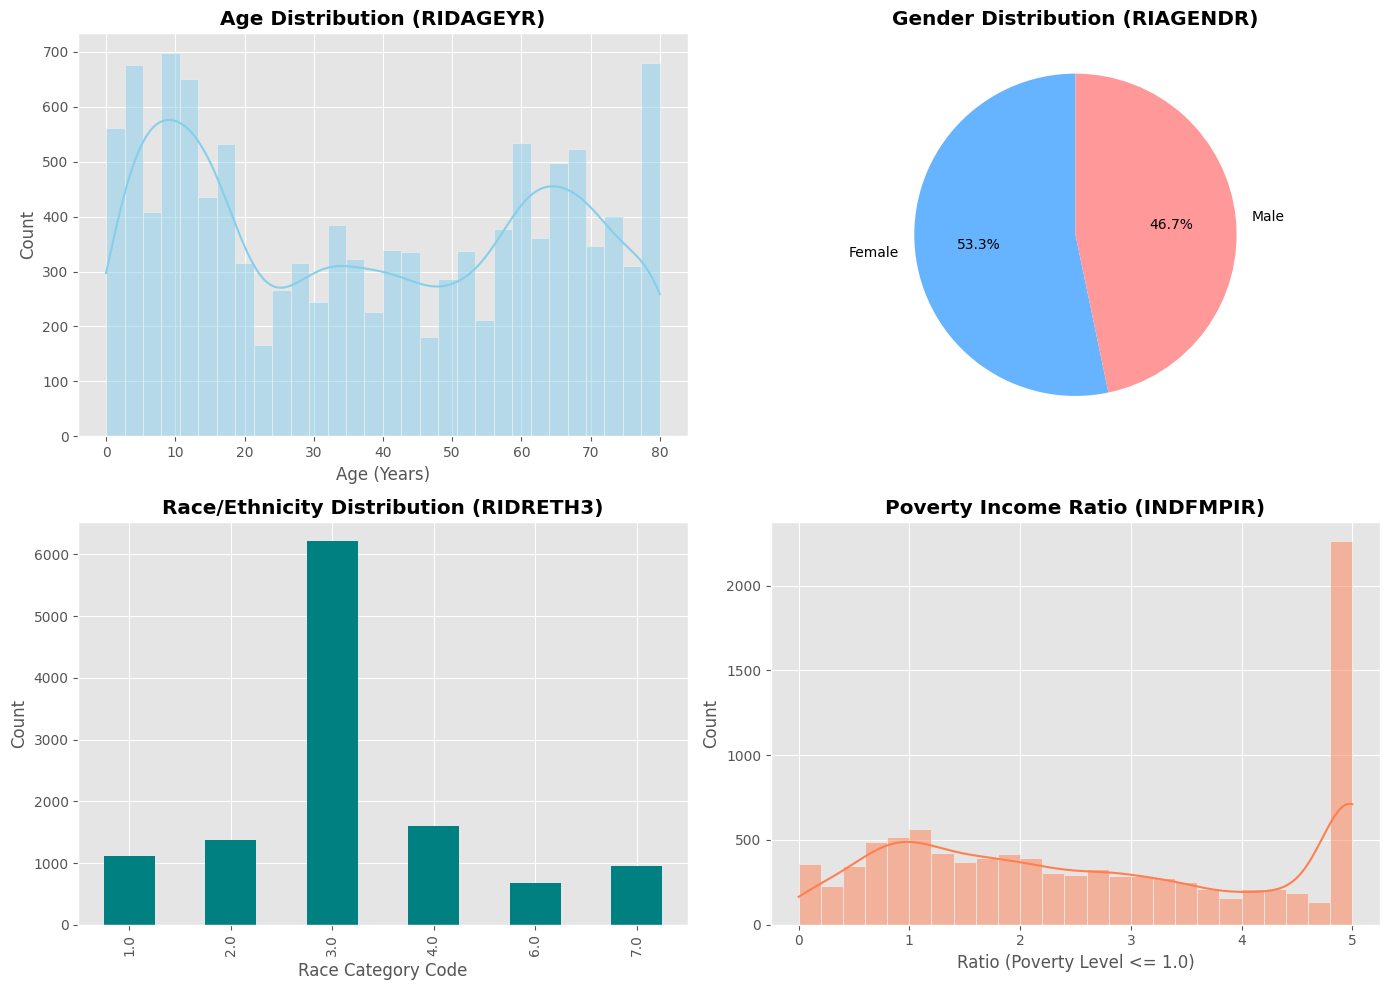

In [9]:
# Key Variable Labels mapping for visualization clarity
gender_map = {1.0: 'Male', 2.0: 'Female'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Age Distribution
sns.histplot(df['RIDAGEYR'].dropna(), bins=30, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Age Distribution (RIDAGEYR)', fontweight='bold')
axes[0, 0].set_xlabel('Age (Years)')
axes[0, 0].set_ylabel('Count')

# 2. Gender Breakdown
gender_counts = df['RIAGENDR'].map(gender_map).value_counts()
gender_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, ax=axes[0, 1], colors=['#66b3ff','#ff9999'])
axes[0, 1].set_title('Gender Distribution (RIAGENDR)', fontweight='bold')
axes[0, 1].set_ylabel('')

# 3. Race / Ethnicity (RIDRETH3)
df['RIDRETH3'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Race/Ethnicity Distribution (RIDRETH3)', fontweight='bold')
axes[1, 0].set_xlabel('Race Category Code')
axes[1, 0].set_ylabel('Count')

# 4. Family Income to Poverty Ratio (INDFMPIR)
sns.histplot(df['INDFMPIR'].dropna(), bins=25, kde=True, ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Poverty Income Ratio (INDFMPIR)', fontweight='bold')
axes[1, 1].set_xlabel('Ratio (Poverty Level <= 1.0)')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 6. Summary & Insights

### Key Takeaways from `DEMO_L.xpt`:
- **Total Sample Size**: **11,933 participants**.
- **Total Features**: **27 demographic & sampling variables**.
- **Participant Age Range**: 0 to 80+ years.
- **Key Features Included**:
  - Unique Identifier: `SEQN`
  - Demographics: Gender (`RIAGENDR`), Age (`RIDAGEYR`, `RIDAGEMN`), Race/Ethnicity (`RIDRETH1`, `RIDRETH3`), Marital Status (`DMDMARTZ`), Education (`DMDEDUC2`)
  - Household: Size (`DMDHHSIZ`), Household reference info (`DMDHRGND`, `DMDHRAGZ`, `DMDHREDZ`, etc.)
  - Socioeconomic: Family Poverty Income Ratio (`INDFMPIR`)
  - Survey Sample Weights: Interview weight (`WTINT2YR`), Examination weight (`WTMEC2YR`), Strata (`SDMVSTRA`), PSU (`SDMVPSU`)